In [18]:
import gdsfactory as gf
from gsim.palace import DrivenSim

gf.gpdk.PDK.activate()

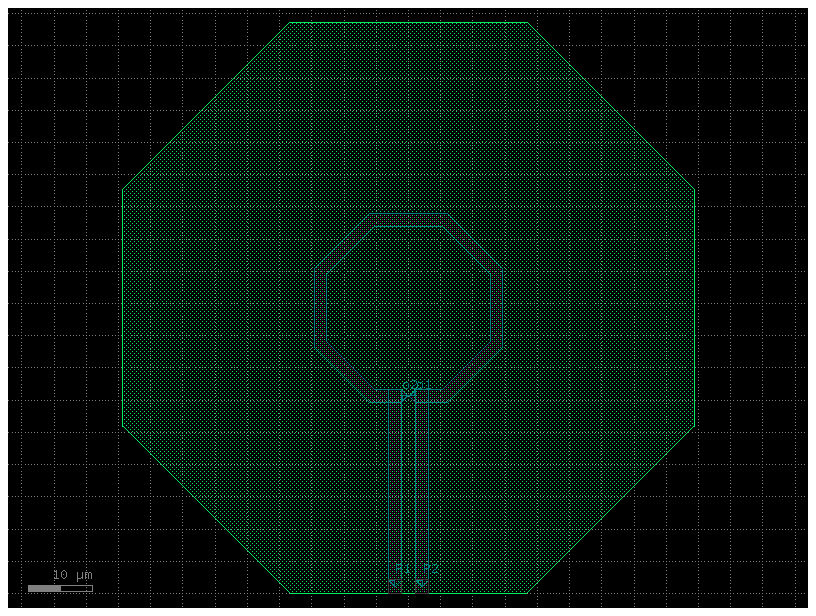

In [19]:
c = gf.components.inductor(
    width=2, 
    space=2.1, 
    diameter=25.35, 
    resistance=0.578, 
    inductance=0.0, 
    turns=1, 
    layer_metal='M3', 
    layer_inductor='M1', 
    layer_metal_pin='WG_PIN', 
    layers_no_fill=('DEVREC', 'NO_TILE_SI')).copy()

cc = c.copy()
cc.draw_ports()

cc.plot()


In [20]:
c.ports

["Port(self.name='o1', self.width=2000, trans=r180 *1 1.05,30.685, layer=M3 (49/0), port_type=optical)", "Port(self.name='o2', self.width=2000, trans=r0 *1 -1.05,30.685, layer=M3 (49/0), port_type=optical)", "Port(self.name='P1', self.width=2100, trans=r270 *1 -2.1,2.1, layer=M3 (49/0), port_type=optical)", "Port(self.name='P2', self.width=2100, trans=r270 *1 2.1,2.1, layer=M3 (49/0), port_type=optical)"]

In [21]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-inductor")
sim.set_geometry(c)

sim.set_stack(
    substrate_thickness=2.0,
    air_above=200.0,
)

sim.add_port("o1",layer="metal3")
sim.add_port("o2",layer="metal3")
sim.add_port("P1",layer="metal3")
sim.add_port("P2",layer="metal3")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [22]:
sim.mesh(preset="default")

Mesh Summary
Dimensions: 288.7 x 288.7 x 307.6 µm
Nodes:      1,207
Elements:   9,733
Tetrahedra: 6,769
Edge length: 0.03 - 204.13 µm
Quality:    0.400 (min: 0.000)
SICN:       0.446 (all valid)
----------------------------------------
Volumes (4):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - airbox [4]
Surfaces (9):
  - metal1_xy [5]
  - metal1_z [6]
  - metal3_xy [7]
  - metal3_z [8]
  - P1 [9]
  - P2 [10]
  - P3 [11]
  - P4 [12]
  - Absorbing_boundary [13]
----------------------------------------
Mesh:   ../palace-sim-inductor/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:48:33.813 (11556.688s) [    732A1DC35080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:48:33.823 (11556.698s) [    732A1DC35080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:48:33.868 (11556.742s) [    732A1DC35080

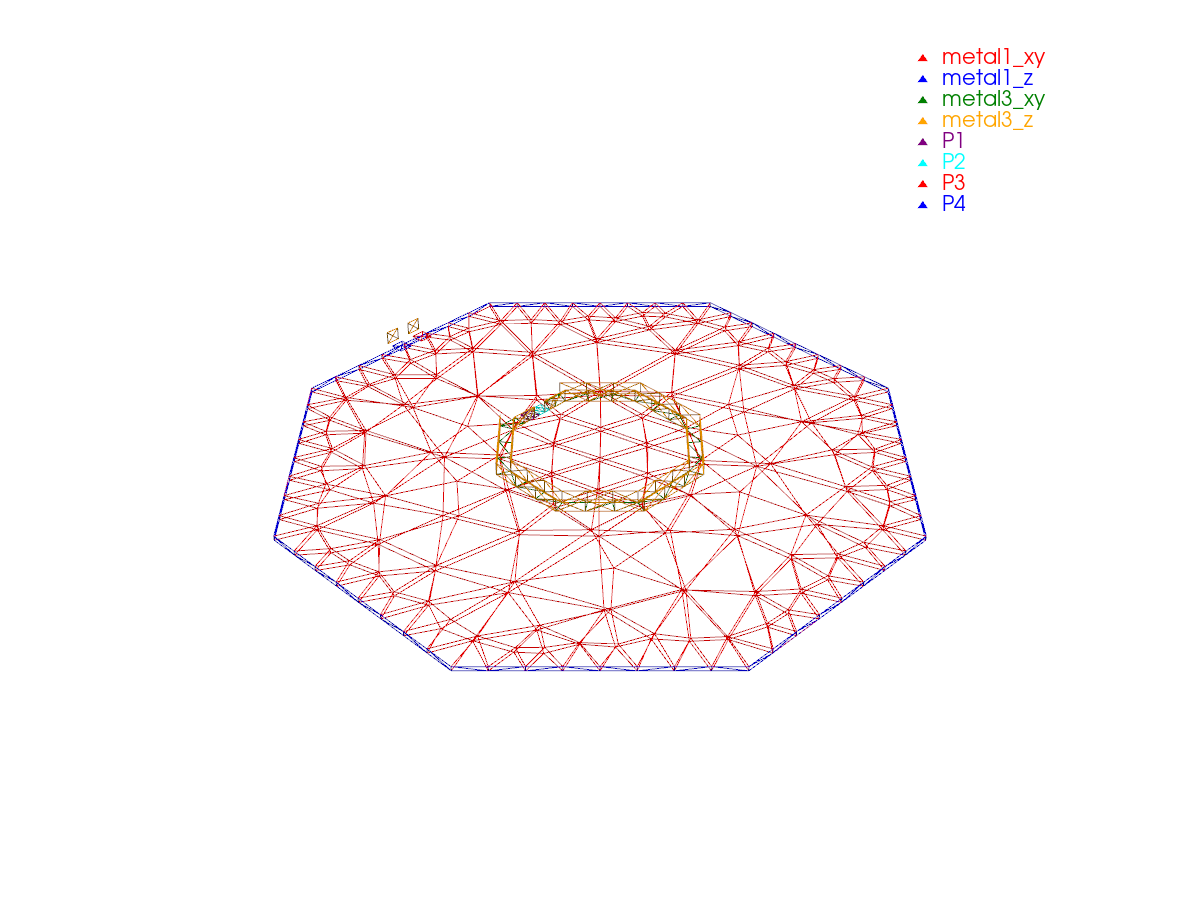

In [23]:
sim.plot_mesh(show_groups=["metal","P"],interactive=False)